# Interactive analysis buttons on `nfigure` (ipympl)

`nfigure(..., fit_button=True, peak_button=True, freq_button=True)` adds extra buttons to the
ipympl toolbar. Each opens a small analysis tool on the axes you last clicked:

| button | what it does |
|---|---|
| **Peak** | *Click 1* draws the centre / FWHM overlay. *Click 2* opens a panel to tune it (background points, background model, peak / step / auto mode). |
| **Fit** | Opens an lmfit panel: pick components, select a range on the plot, guess / preview / run the fit, read the report and copy the code. |
| **Freq** | Opens a frequency-analysis panel (Welch, periodogram, Lomb-Scargle, spectrogram, wavelet). Press **Run** in the panel to get the result in a second figure. |

The panels appear **below the figure**. Drag a panel's bottom-right corner to resize it.

All data here comes from `escape.storage.example_data`, so no beamline files are needed.

In [1]:
%matplotlib widget
import _devpath; _devpath.prepend_local_checkout_to_path()   # use this checkout, not an installed copy
import numpy as np
import escape
from escape.storage.example_data import make_scan
from escape.plot_utilities import nfigure
print("escape from:", escape.__file__)

escape from: /home/lemke_h/mypy/escape-fel/escape/__init__.py


## 1. A peak: Peak and Fit buttons

A Gaussian line profile on a slowly sloping background, one scan step per point.
Try: **Peak** (once for the overlay, again for the panel), then **Fit** → *Run fit*.

Output()

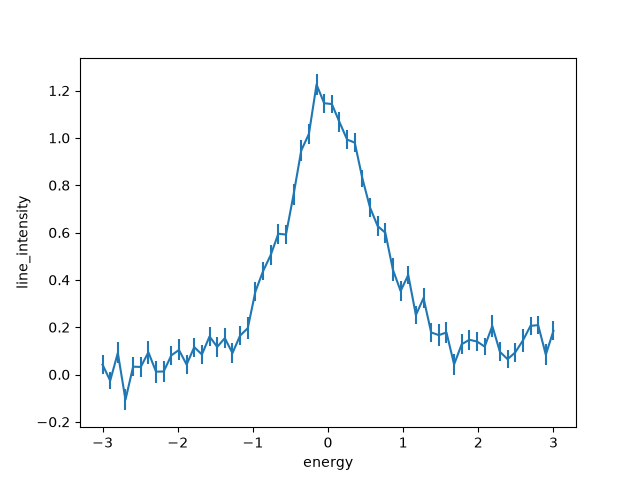

In [3]:
x0, w = 0.0, 0.6
peak = make_scan(
    n_steps=60, n_events_per_step=200, scan_par_name="energy",
    scan_par_values=np.linspace(-3, 3, 60),
    signal_fn=lambda e: 0.1 + 0.02 * e + 1.0 * np.exp(-0.5 * ((e - x0) / w) ** 2),
    noise=0.6, name="line_intensity", seed=1,
)
fig = nfigure("peak demo", fit_button=True, peak_button=True)
peak.scan.plot()

## 2. A step: Peak in *step* mode

A pump-probe-like rise. For a step, the Peak overlay reports the position and width of the edge rather than a peak
(*mode = auto* picks this; you can force it in the panel).

Output()

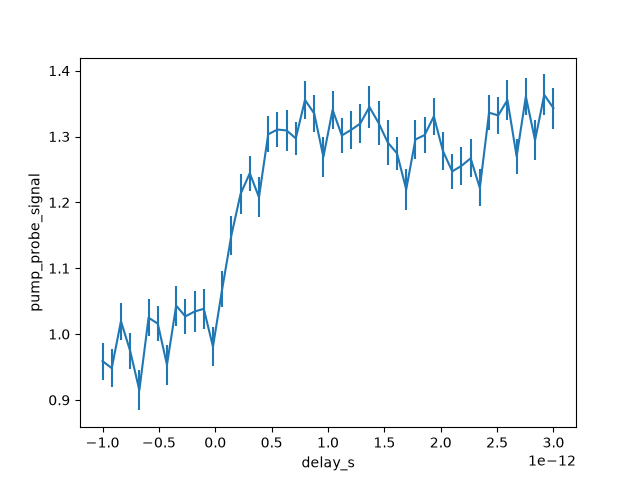

In [4]:
tau = 0.25e-12
step = make_scan(
    n_steps=50, n_events_per_step=300, scan_par_name="delay_s",
    scan_par_values=np.linspace(-1e-12, 3e-12, 50),
    signal_fn=lambda t: 1.0 + 0.3 * (1 - np.exp(-max(t, 0) / tau)) * (t > 0),
    noise=0.5, name="pump_probe_signal", seed=2,
)
fig = nfigure("step demo", peak_button=True, fit_button=True)
step.scan.plot()

## 3. An oscillation: the Freq button

A damped coherent oscillation (~2.5 THz) sampled on a uniform delay grid.
Click **Freq**, choose an analysis, press **Run**. The spectrum appears in a second figure below;
pressing Run again with another method updates it in place.

Output()

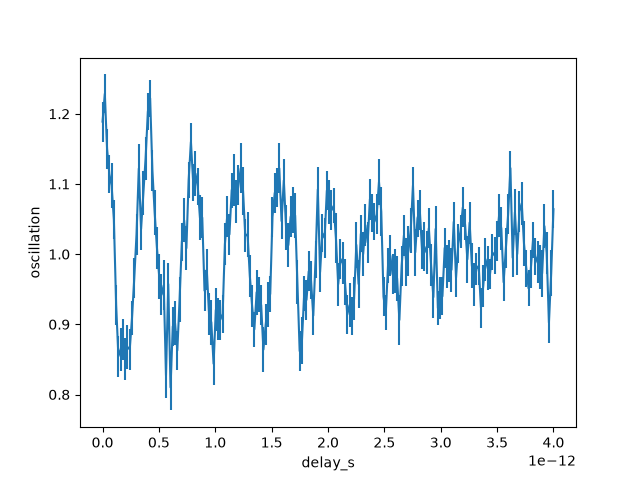

In [5]:
f_thz = 2.5e12
osc = make_scan(
    n_steps=200, n_events_per_step=100, scan_par_name="delay_s",
    scan_par_values=np.linspace(0, 4e-12, 200),
    signal_fn=lambda t: 1.0 + 0.2 * np.exp(-t / 2e-12) * np.cos(2 * np.pi * f_thz * t),
    noise=0.3, name="oscillation", seed=3,
)
fig = nfigure("freq demo", freq_button=True, fit_button=True, peak_button=True)
osc.scan.plot()

## Notes

* Buttons are **Qt / ipympl only**; they're a harmless no-op on other backends.
* The Fit button needs `lmfit`; the Freq wavelet option needs `PyWavelets`.
* Set `escape.plot_utilities.ESCAPE_TOOLBAR_BUTTONS = False` (or the env var `ESCAPE_DISABLE_TOOLBAR_BUTTONS=1` before importing)
  to disable all of them globally.
* On a JupyterHub the **front-end** `jupyter-matplotlib` extension must send `buttons` in mouse events when
  matplotlib >= 3.10 is used; otherwise zoom/pan (and these buttons' plots) silently do nothing.